# Unit 11 Artefact 2: Reproducing Ridley's Autonomous Cyber Defence Experiment

Ian Stevens, Security and Risk Management, Unit 11.

Ridley (2018) describes NSA research into an autonomous cyber defence system and reports one experiment: a reinforcement learning (RL) agent defending an 18-node network against a randomised attacker. The agent kept an average of about 16 of the 18 nodes safe, and the article concludes that RL 'can be used to develop an autonomous cyber defense system'. The article gives no comparison with a simple rule, so there is no way to tell from it whether learning added anything.

This notebook does four things.

1. It checks the arithmetic in the article.
2. It rebuilds the experiment from the description: the network in Figure 3, the three node conditions, the three actions and their costs, the spreading and intrusion probabilities, and the reward.
3. It trains a linear Q-learning agent on the features the article lists, three times with different random seeds.
4. It compares the agent with doing nothing, acting at random, and three one-line rules, and tests how the answer changes when the attacker spreads faster.

The source code in the article's reference [4] (Seita, 2016) is an internal NSA report, so some details had to be assumed. Each assumption is stated where it is made. All policies face the same attacker: every episode's random numbers are drawn before the episode starts, so each policy meets the same sequence of spreading and intrusion attempts (common random numbers, as in Units 8 to 10).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "lines.linewidth": 2,
})
BLUE, ORANGE, AQUA, VIOLET, INK, RED = "#2a78d6", "#eb6834", "#1baf7a", "#7c5cd6", "#52514e", "#c23b3b"
pd.set_option("display.width", 160)

## 1. Checking the arithmetic

The article gives three worked numbers.

* With spreading probability $p = 0.25$ and one compromised node next to two safe ones, the chance of compromising both is $0.25^2$, exactly one is $0.375$, and neither is $0.75^2$.
* With random intrusion probability 0.1 on three safe nodes, the chance that all three are compromised at once is $0.1^3$.
* The chance that the attacker never compromises any node in a 100-turn episode is given as $(0.98^{18})^{100} \approx 0$.

In [2]:
print("both compromised        ", 0.25**2)
print("exactly one compromised ", 2 * 0.25 * 0.75)
print("neither compromised     ", 0.75**2)
print("all three intruded      ", 0.1**3)
print()
print("(0.98^18)^100, as printed:            ", f"{(0.98**18)**100:.2e}")
print("(0.99^18)^100, with the stated q=0.01:", f"{(0.99**18)**100:.2e}")

both compromised         0.0625
exactly one compromised  0.375
neither compromised      0.5625
all three intruded       0.0010000000000000002

(0.98^18)^100, as printed:             1.61e-16
(0.99^18)^100, with the stated q=0.01: 1.39e-08


The first two checks are right. The third uses 0.98 where the experiment's stated intrusion probability of 0.01 gives 0.99. The conclusion survives, since both numbers are effectively zero, but it is a slip in the one figure that ties the text to the experiment's parameters.

## 2. Rebuilding the experiment

**Network.** Figure 3 shows a central hub joined to four nodes, three of which carry 5, 3 and 5 leaves: 18 nodes and 17 links. **Node conditions:** 0 safe, 1 compromised and connected, 2 compromised and isolated. **Actions** (one node per turn): do nothing (cost 0), patch (cost 5) or isolate (cost 10). **Reward:** safe nodes minus the cost of the action. **Attacker:** each connected compromised node infects each safe neighbour with probability 0.15, then each safe node is compromised at random with probability 0.01. **Score:** the average number of safe nodes over the 100 turns of an episode.

Three details are not in the article and are assumed here:

* *Order of play.* The defender acts first, then the attacker spreads, then random intrusion.
* *Patching a connected node.* The article says the compromise 'has some chance of spreading before the agent completes the fix'. Here the node can spread during the attacker's move and is safe at the end of the turn.
* *Isolating.* An isolated node stops spreading at once but stays compromised until patched, which 'costs the agent another time step'.

In [3]:
import numpy as np
from collections import deque

# Figure 3 of Ridley (2018): centre hub with four neighbours; three of them carry 5, 3 and 5 leaves
EDGES = [(0,1),(0,2),(0,3),(0,4)] + [(1,k) for k in range(5,10)] + [(3,k) for k in range(10,13)] + [(4,k) for k in range(13,18)]
N = 18
ADJ = [[] for _ in range(N)]
for a,b in EDGES:
    ADJ[a].append(b); ADJ[b].append(a)
DIRECTED = [(a,b) for a,b in EDGES] + [(b,a) for a,b in EDGES]
COST = {"nothing":0, "patch":5, "isolate":10}

def draws(seed, turns=100):
    r = np.random.default_rng(seed)
    return r.random((turns, len(DIRECTED))), r.random((turns, N))

def step(state, action, spread_u, intr_u, p=0.15, q=0.01):
    """One turn. action = ('nothing',None) | ('patch',i) | ('isolate',i). Returns new state, cost."""
    s = state.copy()
    kind, i = action
    pending_patch = None
    if kind == "isolate":
        s[i] = 2
    elif kind == "patch":
        if s[i] == 2: s[i] = 0
        else: pending_patch = i          # fix completes after the attacker's move
    new = s.copy()
    for k,(a,b) in enumerate(DIRECTED):  # spreading from compromised, non-isolated nodes
        if s[a] == 1 and s[b] == 0 and spread_u[k] < p:
            new[b] = 1
    if pending_patch is not None: new[pending_patch] = 0
    for j in range(N):                   # random intrusion on safe nodes
        if new[j] == 0 and intr_u[j] < q:
            new[j] = 1
    return new, COST[kind]

In [4]:
def valid_actions(s):
    acts = [("nothing", None)]
    for i in range(N):
        if s[i] == 1: acts += [("patch", i), ("isolate", i)]
        elif s[i] == 2: acts.append(("patch", i))
    return acts

def _longest_path(s, label):
    # longest simple path (in nodes) within the induced forest of nodes with this label
    nodes = [i for i in range(N) if s[i] == label]
    if not nodes: return 0
    seen, best = set(), 0
    def bfs(src, comp_only):
        dist = {src:0}; dq = deque([src]); far = src
        while dq:
            u = dq.popleft()
            for v in ADJ[u]:
                if s[v] == label and v not in dist:
                    dist[v] = dist[u]+1; dq.append(v)
                    if dist[v] > dist[far]: far = v
        return far, dist
    for n in nodes:
        if n in seen: continue
        far, dist = bfs(n, True); seen.update(dist)
        far2, dist2 = bfs(far, True)
        best = max(best, dist2[far2] + 1)
    return best

def features(s, kind):
    c = [int(np.sum(s == k)) for k in (0,1,2)]
    lp = [_longest_path(s, k) for k in (0,1,2)]
    maxdeg0 = max([sum(1 for v in ADJ[i] if s[v] == 0) for i in range(N) if s[i] == 0], default=0)
    # spread pressure: safe nodes adjacent to an active compromise (not in Ridley's list; kept out of the base set)
    return np.array([1.0, c[0]/18, c[1]/18, c[2]/18, lp[0]/18, lp[1]/18, lp[2]/18, maxdeg0/5,
                     kind=="patch", kind=="isolate"], dtype=float)

def afterstate(s, action):
    a = s.copy(); kind, i = action
    if kind == "isolate": a[i] = 2
    elif kind == "patch": a[i] = 0
    return a

## 3. Baselines and rules

Five policies need no learning at all:

* **Do nothing.**
* **Random:** any valid action, chosen uniformly.
* **Patch rule:** patch the connected compromise with the most safe neighbours; when there is none, patch an isolated node.
* **Isolate rule:** the same, but isolate first.
* **Hybrid rule:** isolate a connected compromise that touches two or more safe nodes (in this network, a hub), and patch anything else.

In [5]:
def run_episode(policy, seed, p=0.15, q=0.01, turns=100, record=False):
    su, iu = draws(seed, turns)
    s = np.zeros(N, dtype=np.int8); safe = []; costs = 0; kinds = {"nothing":0,"patch":0,"isolate":0}
    for t in range(turns):
        a = policy(s)
        kinds[a[0]] += 1
        s, c = step(s, a, su[t], iu[t], p, q)
        costs += c; safe.append(int(np.sum(s == 0)))
    return np.mean(safe), costs, kinds

def pol_nothing(s): return ("nothing", None)

def make_random(seed=0):
    r = np.random.default_rng(seed)
    def pol(s):
        acts = valid_actions(s); return acts[r.integers(len(acts))]
    return pol

def pol_patch_rule(s):
    """Patch the active compromise with most safe neighbours; otherwise patch an isolated node."""
    active = [i for i in range(N) if s[i] == 1]
    if active:
        i = max(active, key=lambda i: (sum(s[v]==0 for v in ADJ[i]), len(ADJ[i])))
        return ("patch", i)
    iso = [i for i in range(N) if s[i] == 2]
    return ("patch", iso[0]) if iso else ("nothing", None)

def pol_isolate_rule(s):
    """Isolate the active compromise with most safe neighbours; patch isolated nodes when nothing is active."""
    active = [i for i in range(N) if s[i] == 1]
    if active:
        i = max(active, key=lambda i: (sum(s[v]==0 for v in ADJ[i]), len(ADJ[i])))
        return ("isolate", i)
    iso = [i for i in range(N) if s[i] == 2]
    return ("patch", iso[0]) if iso else ("nothing", None)

In [6]:
def pol_hybrid_rule(s):
    """Isolate an active compromise that touches two or more safe nodes (a hub); patch anything else."""
    active = [i for i in range(N) if s[i] == 1]
    if active:
        i = max(active, key=lambda i: (sum(s[v]==0 for v in ADJ[i]), len(ADJ[i])))
        return ("isolate", i) if sum(s[v]==0 for v in ADJ[i]) >= 2 else ("patch", i)
    iso = [i for i in range(N) if s[i] == 2]
    return ("patch", iso[0]) if iso else ("nothing", None)

In [7]:
TEST = [10_000 + i for i in range(1000)]          # the same 1,000 test episodes for every policy
rules = {"Do nothing": pol_nothing, "Random": make_random(1), "Patch rule": pol_patch_rule,
         "Isolate rule": pol_isolate_rule, "Hybrid rule": pol_hybrid_rule}
results = {}
for name, pol in rules.items():
    out = [run_episode(pol, s) for s in TEST]
    results[name] = {"safe": np.array([o[0] for o in out]), "cost": np.array([o[1] for o in out])}
base = pd.DataFrame({n: {"mean safe nodes": r["safe"].mean(), "sd": r["safe"].std(),
                         "action cost per episode": r["cost"].mean(),
                         "reward per episode": 100 * r["safe"].mean() - r["cost"].mean()} for n, r in results.items()}).T
print(base.round(2).to_string())

              mean safe nodes    sd  action cost per episode  reward per episode
Do nothing               3.14  1.32                     0.00              313.94
Random                  14.94  2.60                   330.69             1163.36
Patch rule              17.07  1.78                   159.42             1547.69
Isolate rule            17.47  0.22                   266.33             1480.19
Hybrid rule             17.66  0.13                   161.94             1603.88


## 4. Training the RL agent

The agent follows the article: Q-learning with a linear approximation of $Q(s,a)$ over the listed features (the number of nodes in each condition, the longest path of nodes in each condition, and the highest number of safe neighbours of any safe node), a greedy-epsilon policy annealed during training, 10,000 training episodes of 100 turns, and testing with $\epsilon = 0.05$. Because the action changes the state before the attacker moves, the features are computed on the state the action leads to (the 'afterstate'), with two indicators for the type of action. The step size (0.01), discount (0.9) and annealing schedule (from 1 to 0.05 over the first 60% of training) are not given in the article and were chosen here. Rewards are divided by 18 to keep the weights small; this does not change which action is best.

Each training run takes several minutes. It is repeated with three seeds because the article itself found that a longer run did worse (15.9 after 200,000 episodes against 16.3 after 10,000).

In [8]:
def q_policy(w, eps, rng):
    def pol(s):
        acts = valid_actions(s)
        if rng.random() < eps: return acts[rng.integers(len(acts))]
        vals = [w @ features(afterstate(s, a), a[0]) for a in acts]
        return acts[int(np.argmax(vals))]
    return pol

In [9]:
def train_q(episodes=10_000, alpha=0.01, gamma=0.9, eps_start=1.0, eps_end=0.05, anneal=0.6,
            p=0.15, q=0.01, seed=0, turns=100, log_every=None):
    """Linear Q-learning on afterstate features (Ridley's feature list), greedy-epsilon annealed linearly."""
    rng = np.random.default_rng(seed)
    w = np.zeros(10)
    curve = []
    for ep in range(episodes):
        eps = max(eps_end, eps_start - (eps_start - eps_end) * ep / (anneal * episodes))
        su, iu = draws(1_000_000 + seed*100_000 + ep, turns)
        s = np.zeros(N, dtype=np.int8); safe_sum = 0
        acts = valid_actions(s)
        phis = [features(afterstate(s, a), a[0]) for a in acts]
        k = rng.integers(len(acts)) if rng.random() < eps else int(np.argmax([w @ f for f in phis]))
        for t in range(turns):
            a, phi = acts[k], phis[k]
            s2, c = step(s, a, su[t], iu[t], p, q)
            r = (np.sum(s2 == 0) - c) / 18
            safe_sum += np.sum(s2 == 0)
            acts2 = valid_actions(s2)
            phis2 = [features(afterstate(s2, b), b[0]) for b in acts2]
            vals2 = np.array([w @ f for f in phis2])
            k2 = rng.integers(len(acts2)) if rng.random() < eps else int(np.argmax(vals2))
            target = r + (gamma * vals2.max() if t < turns - 1 else 0.0)
            w += alpha * (target - w @ phi) * phi
            s, acts, phis, k = s2, acts2, phis2, k2
        curve.append(safe_sum / turns)
        if log_every and ep % log_every == 0: print(ep, round(eps,3), round(np.mean(curve[-log_every:]),2))
    return w, np.array(curve)

In [10]:
agents = {}
for seed in (1, 2, 3):
    w, curve = train_q(10_000, seed=seed)
    agents[seed] = (w, curve)
    print(f"seed {seed}: weights", np.round(w, 3))

seed 1: weights [ 1.192  6.786 -4.996 -0.598  0.016 -1.    -0.288  0.309 -0.691 -0.58 ]
seed 2: weights [ 1.152  6.862 -5.067 -0.642 -0.047 -1.078 -0.248  0.199 -0.43  -0.616]
seed 3: weights [ 1.168  6.87  -4.916 -0.787 -0.07  -1.069 -0.486  0.262 -0.498 -0.587]


In [11]:
rl_rows = {}
for seed, (w, curve) in agents.items():
    for e in (0.05, 0.0):
        pol = q_policy(w, e, np.random.default_rng(99))
        out = [run_episode(pol, s) for s in TEST]
        safe = np.array([o[0] for o in out]); cost = np.array([o[1] for o in out])
        kinds = {k: sum(o[2][k] for o in out) for k in ("patch", "isolate")}
        rl_rows[f"RL seed {seed}, eps={e}"] = {"mean safe nodes": safe.mean(), "sd": safe.std(),
            "action cost per episode": cost.mean(), "reward per episode": 100 * safe.mean() - cost.mean(),
            "isolations": kinds["isolate"]}
        if e == 0.05: results[f"RL seed {seed}"] = {"safe": safe, "cost": cost}
rl = pd.DataFrame(rl_rows).T
print(rl.round(2).to_string())
print()
print("Ridley (2018): 16.265 after 10,000 training episodes, 15.919 after 200,000, 16.600 with eps = 0")

                     mean safe nodes    sd  action cost per episode  reward per episode  isolations
RL seed 1, eps=0.05            12.70  3.29                   207.26             1062.40      1372.0
RL seed 1, eps=0.0             12.29  3.33                   191.90             1037.19         0.0
RL seed 2, eps=0.05            16.84  1.77                   175.76             1507.87       626.0
RL seed 2, eps=0.0             16.82  1.95                   171.86             1509.68         0.0
RL seed 3, eps=0.05            16.81  1.57                   170.36             1511.02       624.0
RL seed 3, eps=0.0             16.85  1.85                   171.18             1513.58         0.0

Ridley (2018): 16.265 after 10,000 training episodes, 15.919 after 200,000, 16.600 with eps = 0


## 5. Results

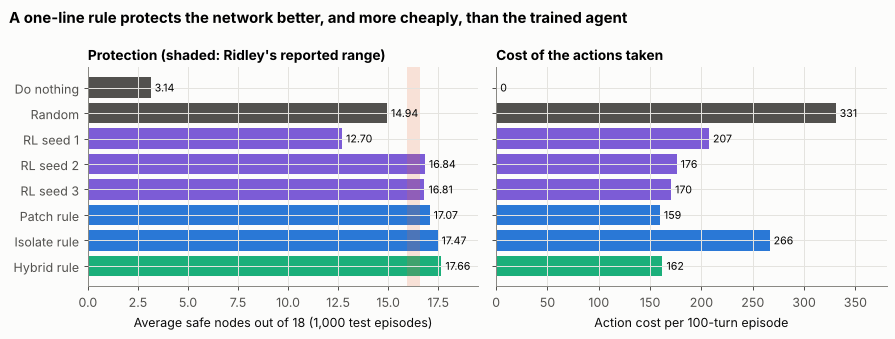

In [12]:
order = ["Do nothing", "Random", "RL seed 1", "RL seed 2", "RL seed 3", "Patch rule", "Isolate rule", "Hybrid rule"]
means = [results[k]["safe"].mean() for k in order]
costs = [results[k]["cost"].mean() for k in order]
cols = [INK, INK, VIOLET, VIOLET, VIOLET, BLUE, BLUE, AQUA]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
ax[0].barh(order, means, color=cols)
ax[0].axvspan(15.919, 16.600, color=ORANGE, alpha=0.18, lw=0)
for i, m in enumerate(means): ax[0].text(m + 0.2, i, f"{m:.2f}", va="center", fontsize=8.5)
ax[0].set_xlim(0, 19.5); ax[0].set_xlabel("Average safe nodes out of 18 (1,000 test episodes)")
ax[0].set_title("Protection (shaded: Ridley's reported range)", loc="left"); ax[0].invert_yaxis()
ax[1].barh(order, costs, color=cols)
for i, c in enumerate(costs): ax[1].text(c + 4, i, f"{c:.0f}", va="center", fontsize=8.5)
ax[1].set_xlabel("Action cost per 100-turn episode"); ax[1].set_title("Cost of the actions taken", loc="left")
ax[1].set_xlim(0, max(costs) * 1.15)
fig.suptitle("A one-line rule protects the network better, and more cheaply, than the trained agent", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig("figures/u11_policies.png", dpi=150, bbox_inches="tight")

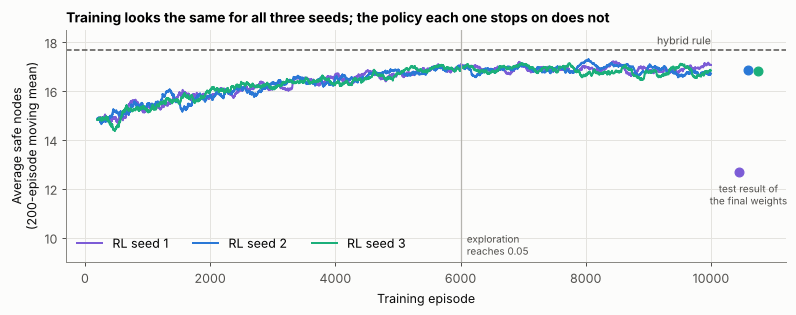

In [13]:
fig, ax = plt.subplots(figsize=(9, 3.6))
k = 200
for seed, colr in zip((1, 2, 3), (VIOLET, BLUE, AQUA)):
    c = agents[seed][1]
    ax.plot(np.arange(k - 1, len(c)), np.convolve(c, np.ones(k) / k, mode="valid"), color=colr, lw=1.6, label=f"RL seed {seed}")
ax.axhline(results["Hybrid rule"]["safe"].mean(), color=INK, ls="--", lw=1.2)
ax.text(10_000, results["Hybrid rule"]["safe"].mean() + 0.25, "hybrid rule", ha="right", fontsize=8.5, color=INK)
ax.axvline(6000, color="#b5b4af", lw=1); ax.text(6100, 9.3, "exploration\nreaches 0.05", fontsize=8, color=INK)
for seed, colr, dx in zip((1, 2, 3), (VIOLET, BLUE, AQUA), (0, 150, 300)):
    ax.plot(10_450 + dx, results[f"RL seed {seed}"]["safe"].mean(), "o", color=colr, ms=7)
ax.text(10_600, 12.25, "test result of\nthe final weights", fontsize=8, color=INK, ha="center", va="top")
ax.set_xlim(-300, 11_200)
ax.set_ylim(9, 18.5); ax.set_xlabel("Training episode"); ax.set_ylabel("Average safe nodes\n(200-episode moving mean)")
ax.set_title("Training looks the same for all three seeds; the policy each one stops on does not", loc="left")
ax.legend(frameon=False, loc="lower left", ncol=3)
fig.tight_layout()
fig.savefig("figures/u11_training.png", dpi=150, bbox_inches="tight")

## 6. How fast can the attacker spread before defence fails?

The article warns that 'if the spreading probability is too high, the RL agent effectively cannot protect the network even if it performed the optimal actions'. That depends on what the agent is allowed to do. The rules are re-run with spreading probabilities from 0.05 to 0.5 on 500 test episodes each.

      Do nothing  Patch rule  Isolate rule  Hybrid rule
0.05        5.56       17.76         17.48        17.72
0.10        3.92       17.68         17.47        17.69
0.15        3.15       17.15         17.46        17.66
0.20        2.72       14.34         17.45        17.63
0.25        2.44       10.51         17.44        17.60
0.30        2.23        7.29         17.44        17.57
0.40        1.95        4.59         17.41        17.49
0.50        1.77        3.65         17.39        17.39


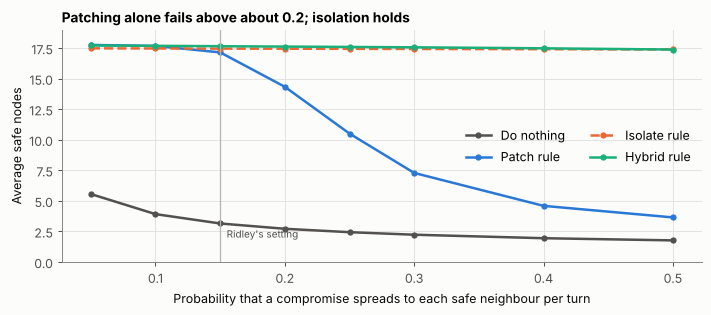

In [14]:
ps = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
sens = {name: [np.mean([run_episode(pol, s, p=p)[0] for s in TEST[:500]]) for p in ps]
        for name, pol in [("Do nothing", pol_nothing), ("Patch rule", pol_patch_rule),
                          ("Isolate rule", pol_isolate_rule), ("Hybrid rule", pol_hybrid_rule)]}
print(pd.DataFrame(sens, index=ps).round(2).to_string())
fig, ax = plt.subplots(figsize=(8, 3.6))
for (name, v), colr, ls in zip(sens.items(), (INK, BLUE, ORANGE, AQUA), ("-", "-", "--", "-")):
    ax.plot(ps, v, marker="o", ms=4, color=colr, ls=ls, label=name)
ax.axvline(0.15, color="#b5b4af", lw=1); ax.text(0.155, 2, "Ridley's setting", fontsize=8, color=INK)
ax.set_xlabel("Probability that a compromise spreads to each safe neighbour per turn")
ax.set_ylabel("Average safe nodes"); ax.set_ylim(0, 19)
ax.set_title("Patching alone fails above about 0.2; isolation holds", loc="left")
ax.legend(frameon=False, ncol=2, loc="center right")
fig.tight_layout()
fig.savefig("figures/u11_spread.png", dpi=150, bbox_inches="tight")

## 7. What this shows

* **The rebuilt experiment lands where the article does.** Two of the three trained agents keep about 16.8 nodes safe with $\epsilon = 0.05$, close to the 16.3 to 16.6 Ridley reports. The assumptions above are therefore close enough to the original to make the comparison fair.
* **Training is unstable.** All three seeds look alike during training, but the weights seed 1 happened to stop on give a policy that keeps only about 12.7 nodes safe in testing. The article found the same kind of instability when a run 20 times longer did worse. A defender that is good or poor depending on when training stops needs to be tested many times before anyone relies on it.
* **The agent never chooses to isolate.** With $\epsilon = 0$ none of the agents isolates a node; the isolations at $\epsilon = 0.05$ are random exploration. Under the article's costs, isolating and then patching a node costs 15 against 5 for patching, and the agent learns to patch only. That is a sensible policy in a model where the reward charges for actions, but it means the agent cannot cope when spreading is fast (Section 6).
* **A one-line rule does better.** The patch rule keeps about 17.1 nodes safe and the hybrid rule about 17.7, at a lower action cost than the trained agents. The isolate rule protects well but spends much more. None of the rules needed 10,000 episodes of training.
* **The score and the reward disagree.** The article reports safe nodes, but the agent is trained on safe nodes minus action costs. A policy can therefore improve its reward while its reported score falls, and the isolate rule shows the reverse. An autonomous defender optimises what it is paid for, so the reward is a risk decision in its own right and needs an owner.

The limits are the same as the article's: equal node values, an attacker with no strategy, one action per turn and perfect visibility of every node's condition. A real attacker would hide, as Ridley's own Table 1 assumes, and detection is where most of the uncertainty lies. The test of any learned defender should therefore be the simplest rule that a human analyst would write, under the same conditions, and the margin it has to beat.